In [1]:
from bam_utils import *

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split, TensorDataset, IterableDataset
from torch.nn import functional as F
from torch.nn import Module, ModuleList
import itertools

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}.")

Using cuda.


In [2]:
from torch.utils.data import IterableDataset, get_worker_info
import torch

class LargeIterableDataset(IterableDataset):
    def __init__(self, file_list, max_samples=None, compute_len=False):
        super().__init__()
        self.file_list = list(file_list)
        self.max_samples = max_samples
        self._length = None
        if compute_len:
            self._length = self._count_windows()

    def _count_windows(self):
        count = 0
        for fname in self.file_list:
            data = torch.load(fname, map_location="cpu")
            n = len(data[0]) if hasattr(data[0], "__len__") else data[0].shape[0]
            count += n
            if self.max_samples and count >= self.max_samples:
                return self.max_samples
        return count

    def __iter__(self):
        info = get_worker_info()
        if info is None:
            files = self.file_list
        else:
            # shard files across workers
            files = self.file_list[info.id::info.num_workers]

        emitted = 0
        for fname in files:
            data = torch.load(fname, map_location="cpu")
            x_all, lb_all, pos_all = data[0], data[1], data[2]

            n = len(x_all)
            for i in range(n):
                yield (x_all[i].float(), lb_all[i], pos_all[i])
                emitted += 1
                if self.max_samples and emitted >= self.max_samples:
                    return

    def __len__(self):
        if self._length is None:
            raise TypeError("Length unknown; set compute_len=True to pre-count.")
        return self._length


In [3]:
mdir = '/home/zouy1/projects/RNAmod/autoencoder/input/input_oligos_7mer_new/'
batch_size=256
nw = 10

train_list = mdir+'/train/'
train_list = list(Path(train_list).rglob("*.pt"))
val_list = mdir+'/val/'
val_list = list(Path(val_list).rglob("*.pt"))
test_list = mdir+'/test/'
test_list = list(Path(test_list).rglob("*.pt"))
mod_list =mdir+'/mod/'
mod_list =list(Path(mod_list).rglob("*.pt"))

### Supervised Model

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader, random_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import itertools, numpy as np

class LabeledIterable(IterableDataset):
    """Yield (tensor, label) where label = 0 for unmod, 1 for mod."""
    def __init__(self, iterable_unmod, iterable_mod):
        super().__init__()
        self.iter_unmod = iterable_unmod
        self.iter_mod   = iterable_mod
    def __iter__(self):
        # interleave the two streams 1:1 for balanced batches
        for un, md in itertools.zip_longest(self.iter_unmod, self.iter_mod):
            if un is not None:
                yield un, 0
            if md is not None:
                yield md, 1

import random
from pathlib import Path

unmod_files = train_list
mod_files   = mod_list

random.seed(42)

split = 0.5  # 20 % to test
cut_unmod = int(len(unmod_files) * split)
cut_mod   = int(len(mod_files)   * split)

unmod_test_files = unmod_files[:cut_unmod]
unmod_train_files= unmod_files[cut_unmod:]

mod_test_files   = mod_files[:cut_mod]
mod_train_files  = mod_files[cut_mod:]

train_unmod = LargeIterableDataset(unmod_train_files)
train_mod   = LargeIterableDataset(mod_train_files)

test_unmod  = LargeIterableDataset(unmod_test_files)
test_mod    = LargeIterableDataset(mod_test_files)

train_ds = LabeledIterable(train_unmod, train_mod)
test_ds  = LabeledIterable(test_unmod,  test_mod)

train_loader = DataLoader(train_ds, batch_size=batch_size, num_workers=nw, pin_memory=True, persistent_workers=True, prefetch_factor=4)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, num_workers=nw, pin_memory=True, persistent_workers=True, prefetch_factor=4)

In [ ]:
# Simple linear classifier

model = nn.Sequential(
    nn.Linear(77, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
).to(device)
print(model)
nparam = sum([p.numel() for p in model.parameters()])
print(f"The total number of params from the current model is {nparam}.")

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=0.001)

#training
for epoch in range(50):
    model.train()
    for x, y in train_loader:
        x, y = x[0].to(device), y.float().to(device)
        x = x.view(x.size(0), -1)
        logits = model(x).squeeze(-1)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"epoch {epoch+1}  loss={loss.item():.4f}")

#evaluate
model.eval()
y_true, y_score = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x[0].to(device)
        x = x.view(x.size(0), -1)
        logits = model(x).squeeze(-1)
        probs  = torch.sigmoid(logits).cpu().numpy()
        y_true.extend(y.numpy())
        y_score.extend(probs)

y_true  = np.array(y_true)
y_score = np.array(y_score)
auc     = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

print(f"Test ROC‑AUC = {auc:.4f}")

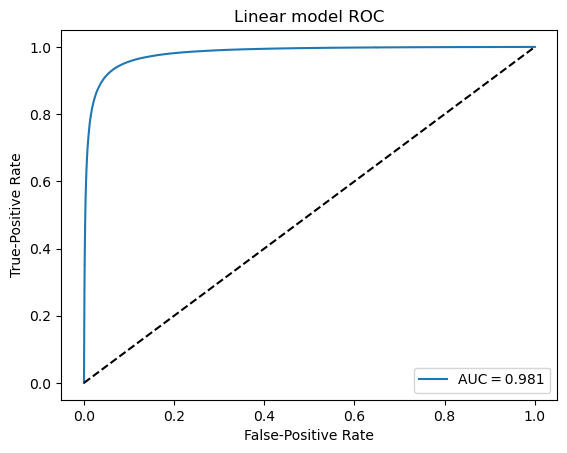

In [7]:
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False‑Positive Rate"); plt.ylabel("True‑Positive Rate")
plt.title("Linear model ROC"); plt.legend()
plt.savefig("ROC_supervisedFFN.png", dpi=300)
plt.show()

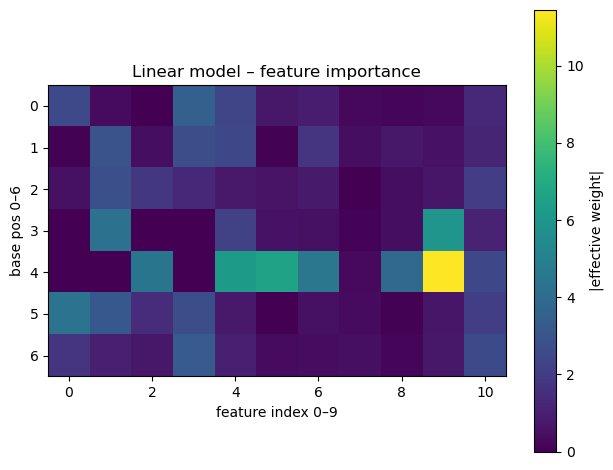

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np

W1 = model[0].weight.detach().cpu()          # (32,70)
W2 = model[2].weight.detach().cpu()          # (1,32)
w_eff = (W2 @ W1).squeeze(0).abs().numpy()   # (70,)

heat = w_eff.reshape(7,11)                   # (row,feature)

plt.imshow(heat, cmap="viridis")
plt.colorbar(label="|effective weight|")
plt.xlabel("feature index 0–9"); plt.ylabel("base pos 0–6")
plt.title("Linear model – feature importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()
